### Introduction to Logistic Regression

**Logistic Regression** is a classification algorithm used to predict binary outcomes: $0$ (**No**) and $1$ (**Yes**) based on a given dataset.

**Example:**
Imagine you need to determine whether a contacted customer will buy a product or not. Your data consists of a sample of recently contacted customers, their `Age`, and a label indicating whether they took action.

**Mechanism:**
Instead of predicting exactly whether a person will buy the product (hard classification), Logistic Regression calculates the **probability** or likelihood of the person saying "Yes".
* **Output:** The model fits probabilities within the range $[0, 1]$.
* **Decision Boundary:** You decide a **threshold** (cut-off value).
    * If $Probability > Threshold \rightarrow$ Predict: **Buy** ($1$).
    * If $Probability < Threshold \rightarrow$ Predict: **Don't Buy** ($0$).

Logistic Regression can be binomial, ordinal, or multinomial. In the binomial or binary logistic regression, the outcoem can have only two possible types of values (e.g. "Yes" or "No", "Success" or "Failture"). Multinomial logistic refers to cases where the outcome can hvae three or more possible types of values (e.g. "good" vs "very good" vs "best"). Generally, the outcome is coded as "0" and "1" in binary logistic regression. Ordinal logistic regression deals with dependent variables that are ordered (e.g. the satisfication of audiences ($\text{Dissatisfied}$, $\text{Neutral}$, $\text{Satisfied}$, $\text{Very satisfied}$). 

### Representation of Logistic Regression

Like a linear regression model, a logistic regression model also computes a weighted sum of input features (and adds  a bias term to it - ($y = a_0+ x_1*a_1 +....+ x_n*a_n$)). However, unlike linear regression, it calculates the logistic of the results so that the output is always between 0 and 1.

Logistic Regression model estimated probability (vectorized form)

$$\hat{p} = h_{\theta}(x) = \sigma(\theta^{T}.x)$$

In this case, $\theta^{T}.x$ like the equation $w_0 + a_1.w_1 + a_2.w_2 +...+ a_n.w_n$ in linear regression

The logistic also called as logit is denoted by $\sigma$ is a sigmoid function and it outputs a number between 0 and 1.

$$\sigma(t) = \frac{1}{1 + e^{-t}}$$

The output of a Logistic regression model is a probability. We can select threshold value. If the probability is greater than this threshold value, the event is predict to happen. Otherwise, it is predicted not to happen.

When the model estimates the probability ($\hat{y}$), it can make the predictions as follows:

$$
\hat{y} =
\begin{cases}
0, \text{ if } \hat{p} < 0.5, \\
1, \text{ if } \hat{p} \geq 0.5.
\end{cases}
$$

### Logistic Regression in Python

In [170]:
#Import Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [205]:
df = pd.read_csv("C:/Users/ADMIN/Desktop/Ok/ML/Logistic_Regression/train.csv")
test_df = pd.read_csv("C:/Users/ADMIN/Desktop/Ok/ML/Logistic_Regression/test.csv")
df.shape

(891, 12)

In [206]:
df.head(10)
test_df.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


### Processing the missing value

In [207]:
for i in df.columns:
    missing_values = df[i].isna().sum()
    missing_percentage = (missing_values/len(df))*100
    print(f"Column {i} is a {df[i].dtype} column and has: {missing_percentage}% missing values")

Column PassengerId is a int64 column and has: 0.0% missing values
Column Survived is a int64 column and has: 0.0% missing values
Column Pclass is a int64 column and has: 0.0% missing values
Column Name is a object column and has: 0.0% missing values
Column Sex is a object column and has: 0.0% missing values
Column Age is a float64 column and has: 19.865319865319865% missing values
Column SibSp is a int64 column and has: 0.0% missing values
Column Parch is a int64 column and has: 0.0% missing values
Column Ticket is a object column and has: 0.0% missing values
Column Fare is a float64 column and has: 0.0% missing values
Column Cabin is a object column and has: 77.10437710437711% missing values
Column Embarked is a object column and has: 0.22446689113355783% missing values


In [208]:
for i in test_df.columns:
    missing_values = test_df[i].isna().sum()
    missing_percentage = (missing_values/len(test_df))*100
    print(f"Column {i} is a {test_df[i].dtype} column and has: {missing_percentage}% missing values")

Column PassengerId is a int64 column and has: 0.0% missing values
Column Pclass is a int64 column and has: 0.0% missing values
Column Name is a object column and has: 0.0% missing values
Column Sex is a object column and has: 0.0% missing values
Column Age is a float64 column and has: 20.574162679425836% missing values
Column SibSp is a int64 column and has: 0.0% missing values
Column Parch is a int64 column and has: 0.0% missing values
Column Ticket is a object column and has: 0.0% missing values
Column Fare is a float64 column and has: 0.23923444976076555% missing values
Column Cabin is a object column and has: 78.22966507177034% missing values
Column Embarked is a object column and has: 0.0% missing values


In [209]:
#For int64 or float64 columns, we will fill the missing values by mean of this column
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')
df[["Age"]] = imputer.fit_transform(df[["Age"]])
test_df[["Age"]] = imputer.transform(test_df[["Age"]])
test_df.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [210]:
#For "Cabin" column, because it has lots of null values, it is better to remove it
df = df.drop("Cabin", axis = 1)
test_df = test_df.drop("Cabin", axis = 1)

In [189]:
print(df['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [211]:
#For "Embarked" column, because there are just two missing values, we will fill it with the element has the most appearances
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)
test_df["Embarked"].fillna(test_df["Embarked"].mode()[0], inplace = True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2460\2950274662.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2460\2950274662.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [212]:
#For "SibSp" and "Parch" columns, we will combine them and convert to "Family" column

def combine(df_clone, col1, col2):
    df_clone["Family"] = df_clone[col1]+df_clone[col2]
    df_clone.drop([col1,col2], inplace = True, axis = 1)
    return df_clone

df = combine(df, "SibSp", "Parch")
test_df = combine(test_df, "SibSp", "Parch")

In [215]:
#df["Age"].describe()
test_df["Age"].describe()

count    418.000000
mean      30.154603
std       12.636666
min        0.170000
25%       23.000000
50%       29.699118
75%       35.750000
max       76.000000
Name: Age, dtype: float64

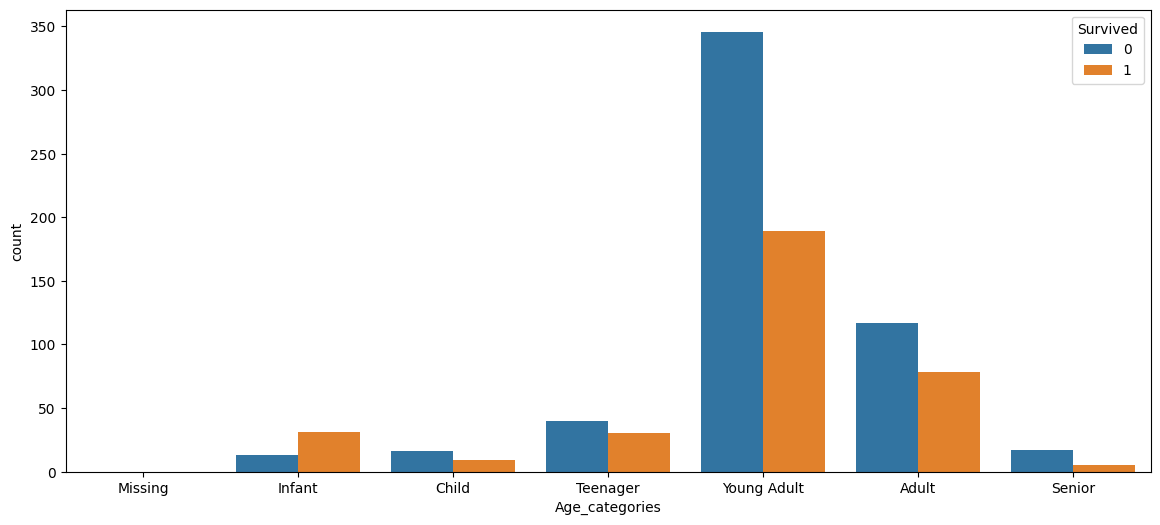

In [216]:
#Divide "Age" into ranges
def process_age(df_clone, cut_points, label_names):
    #df_clone["Age"] = df_clone["Age"].fillna(-0.5)
    df_clone["Age_categories"] = pd.cut(df_clone["Age"], cut_points, labels = label_names)
    return df_clone

cut_points = [-1,0,5,12,18,35,60,100]
label_names = ["Missing", "Infant", "Child", "Teenager", "Young Adult", "Adult", "Senior"]
df = process_age(df, cut_points, label_names)
test_df = process_age(test_df, cut_points, label_names)
df.head(10)

fig, ax = plt.subplots(figsize = (14,6))
ax = sns.countplot(data = df, x = "Age_categories", hue = "Survived")

In [218]:
#Preprocessing the "Fare" column of test_df
from sklearn.impute import SimpleImputer
imputer_1 = SimpleImputer(missing_values = np.nan, strategy = 'mean')
test_df[["Fare"]] = imputer_1.fit_transform(test_df[["Fare"]])

### Encoding Categorical Variables

In [219]:
def create_dummies(df_clone, column_name):
    dummies = pd.get_dummies(df_clone[column_name], prefix = column_name, drop_first = True, dtype = 'int64')
    df_clone = pd.concat([df_clone, dummies], axis = 1)
    return df_clone

column_name = ["Pclass", "Sex", "Age_categories", "Embarked"]

for i in column_name:
    df = create_dummies(df, i)
    test_df = create_dummies(test_df, i)
#df.head(10)

df = df.drop(column_name, axis = 1)
test_df = test_df.drop(column_name, axis = 1)

df.head(10)

,PassengerId,Survived,Name,Age,Ticket,Fare,Family,Pclass_2,Pclass_3,Sex_male,Age_categories_Infant,Age_categories_Child,Age_categories_Teenager,Age_categories_Young Adult,Age_categories_Adult,Age_categories_Senior,Embarked_Q,Embarked_S
0,1,0,"Braund, Mr. Owen Harris",22.000000,A/5 21171,7.2500,1,0,1,1,0,0,0,1,0,0,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.000000,PC 17599,71.2833,1,0,0,0,0,0,0,0,1,0,0,0
2,3,1,"Heikkinen, Miss. Laina",26.000000,STON/O2. 3101282,7.9250,0,0,1,0,0,0,0,1,0,0,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.000000,113803,53.1000,1,0,0,0,0,0,0,1,0,0,0,1
4,5,0,"Allen, Mr. William Henry",35.000000,373450,8.0500,0,0,1,1,0,0,0,1,0,0,0,1
5,6,0,"Moran, Mr. James",29.699118,330877,8.4583,0,0,1,1,0,0,0,1,0,0,1,0
6,7,0,"McCarthy, Mr. Timothy J",54.000000,17463,51.8625,0,0,0,1,0,0,0,0,1,0,0,1
7,8,0,"Palsson, Master. Gosta Leonard",2.000000,349909,21.0750,4,0,1,1,1,0,0,0,0,0,0,1
8,9,1,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.000000,347742,11.1333,2,0,1,0,0,0,0,1,0,0,0,1
9,10,1,"Nasser, Mrs. Nicholas (Adele Achem)",14.000000,237736,30.0708,1,1,0,0,0,0,1,0,0,0,0,0


### Exploratory Data Analysis (EDA)

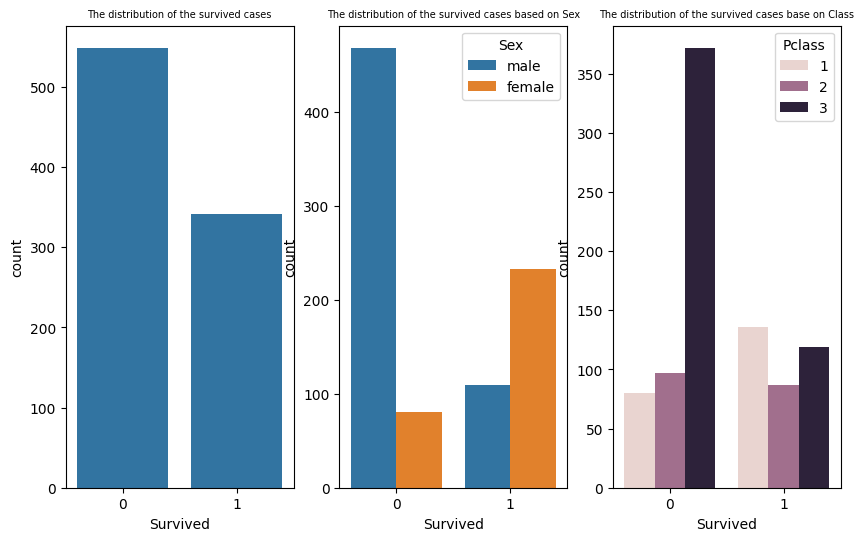

In [175]:
#Examining the Distribution of the Target Column
fig = plt.figure(figsize = (10,6))

ax = fig.add_subplot(131)
sns.countplot(data = df, x = "Survived")
title = "The distribution of the survived cases"
ax.set_title(title, loc = 'center', fontsize = 7);

ax = fig.add_subplot(132)
sns.countplot(data = df, x = "Survived", hue = "Sex")
title = "The distribution of the survived cases based on Sex"
ax.set_title(title, loc = 'center', fontsize = 7);

ax = fig.add_subplot(133)
sns.countplot(data = df, x = "Survived", hue = "Pclass")
title = "The distribution of the survived cases base on Class"
ax.set_title(title, loc = 'center', fontsize = 7);

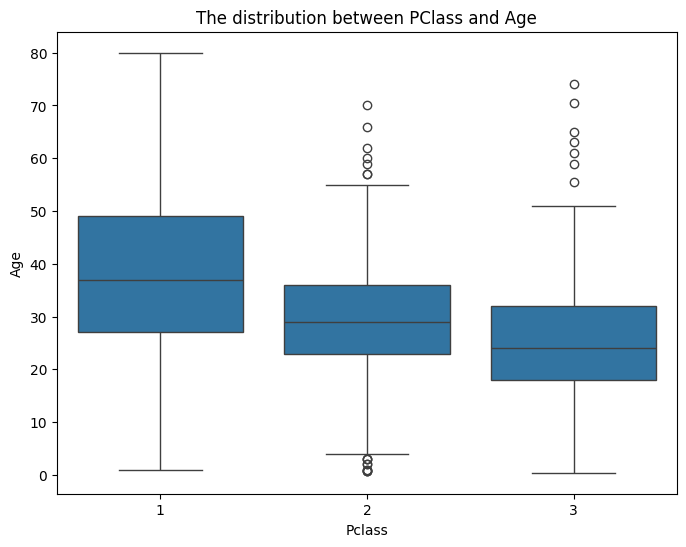

In [28]:
fig, ax = plt.subplots(figsize = (8,6))

sns.boxplot(data = df, x = "Pclass", y = "Age");
ax.set_title("The distribution between PClass and Age");

### Logistic Regression Implementation

In [221]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

df = df.drop("Name", axis = 1)
df = df.drop("Ticket", axis = 1)

test_df = test_df.drop("Name", axis = 1)
test_df = test_df.drop("Ticket", axis = 1)

train_columns = []
for i in df.columns.values:
    if (i != "Survived"):
        train_columns.append(i)
lr.fit(df[train_columns], df["Survived"])

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [196]:
from sklearn.model_selection import train_test_split
X = df[train_columns]
y = df['Survived']

train_X, test_X, train_y, test_y = train_test_split(X,y, test_size = 0.2, random_state = 0)

### Evaluate the accuracy

In [198]:
from sklearn.metrics import accuracy_score
lr = LogisticRegression()
lr.fit(train_X, train_y)
y_predict = lr.predict(test_X)
accuracy = accuracy_score(test_y, y_predict)
print(accuracy)

0.7932960893854749


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [222]:
lr = LogisticRegression()
lr.fit(X,y)
y_pred = lr.predict(test_df)

C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [225]:
answer = pd.DataFrame({"PassengerId": test_df["PassengerId"], "Survived": y_pred})
answer.head(20)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [226]:
answer.to_csv("titanic.csv", index = False)